## Predicting House Price with Multiple Linear Regression

This is a real estate dataset to perform Exploratory Data Analysis (EDA) and create a Multiple Linear Regression (MLR) model to predict the Price of a house based on various features such as Square Feet, Number of Bedrooms, Number of Bathrooms, and other factors.

**This was a joint project with a Team mate.**

## Loading and Understanding the Data

Load the dataset into a Pandas DataFrame using the CSV file in Blob Storage, named df_house_price. 

Connect to Azure Blob Storage using a connection string that has the authentication details. 


In [2]:
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

## this authentication for blob service client, i named the var bsc, it means (Blob Serivce client)
bsc = BlobServiceClient.from_connection_string(connect_str)

##this is the container client
cc = bsc.get_container_client(container_name)

##this is to get the blob name
bc = cc.get_blob_client(blob_name)

## this is convert this data into a csv then into a data frame, then display the Dataframe
csv_content = bc.download_blob().readall().decode('utf-8')
df_house_price = pd.read_csv(StringIO(csv_content))

display(df_house_price.head(3))

##checking for missing values. then displaying it
missing = df_house_price.isnull()
mdf = df_house_price[missing.any(axis=1)]

display(mdf)

##check the data types'
print(df_house_price.dtypes)

Square_Feet           float64
Num_Bedrooms            int64
Num_Bathrooms           int64
Num_Floors              int64
Garage_Size             int64
Location_Score        float64
Distance_to_Center    float64
Price                 float64
dtype: object


## Exploratory Data Analysis (EDA)

Perform some basic EDA to understand the relationships between the features and the target variable (Price). This includes visualising the data, checking for correlations, and identifying patterns.

Install seaborn and matplotlib so we can make visualisations. 


In [3]:
##download seaborn so we can make graphs
!pip install seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 10.3 MB/s eta 0:00:00


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Have a look at the data
display(df_house_price.describe())

Let's make some visualisations to understand the data

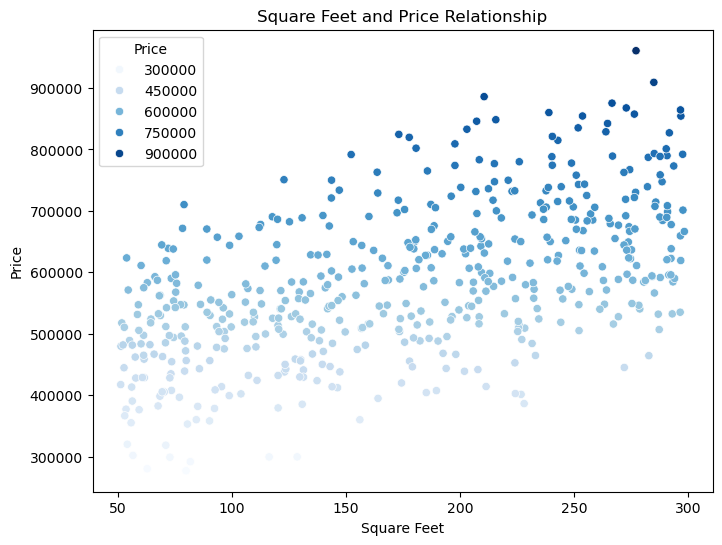

In [5]:
##scatter plot between Square feet and Price
plt.figure(figsize=(8,6))
sns.scatterplot(x='Square_Feet',y='Price',data=df_house_price,hue='Price', palette='Blues')
plt.title('Square Feet and Price Relationship')
plt.xlabel('Square Feet')
plt.ylabel('Price')
plt.show()

**Result:**
The scatter plot shows a positive relationship between Square Feet and Price. Generally, larger houses tend to have higher prices, although there is some variation in prices for houses of similar sizes.')


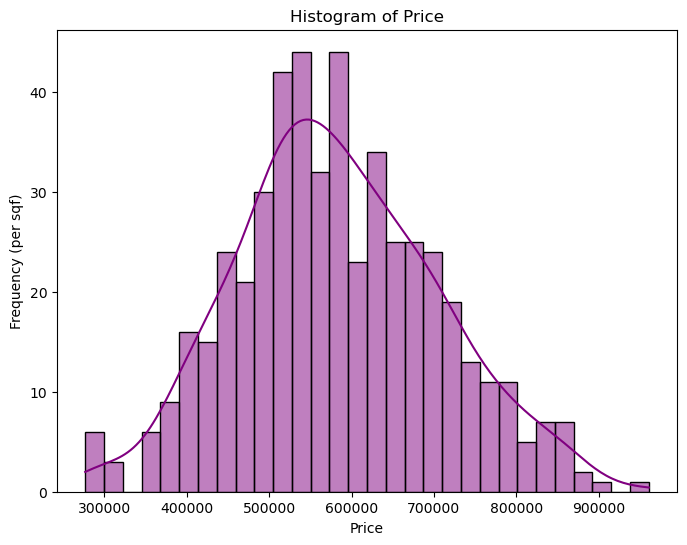

In [6]:
##Histogram of price (task 2.3)
plt.figure(figsize=(8,6))
sns.histplot(df_house_price['Price'], bins=30, color='purple', kde=True)
plt.title('Histogram of Price')
plt.xlabel('Price')
plt.ylabel('Frequency (per sqf)')
plt.show()

**Result:**
The histogram shows the distribution of house prices across the dataset. Most properties are concentrated within the middle price range, with fewer properties at the very low and very high price ranges.


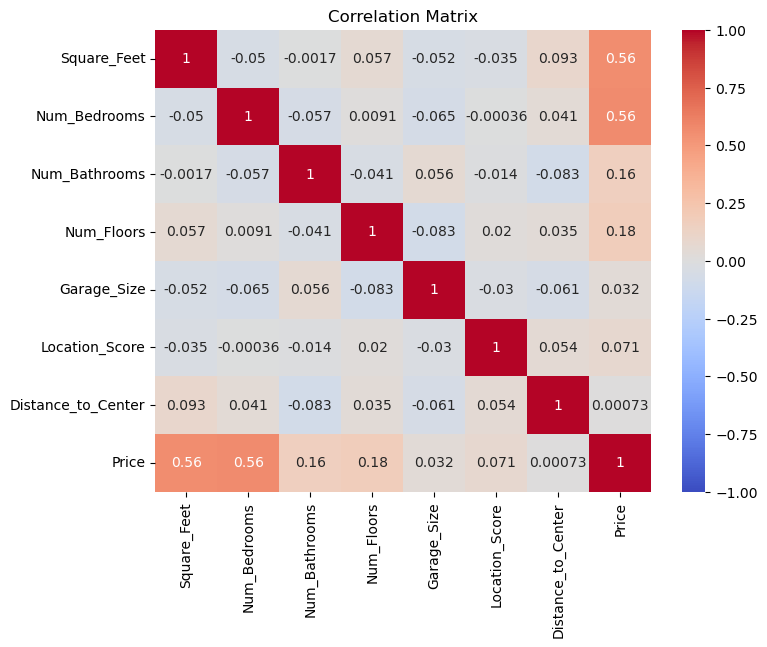

In [7]:
## Correlation matrix and heatmap (task 2.4)
cm = df_house_price.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,cmap='coolwarm',vmin=-1,vmax=1)
plt.title('Correlation Matrix')
plt.show()

**Result:**
The heatmap shows a positive correlation between Square Feet and Price, indicating that larger houses generally have higher prices. Other features show varying levels of correlation with Price, suggesting that multiple factors influence house prices

## Create a Multiple Linear Regression (MLR) Model

We will use Multiple Linear Regression to predict the Price of the house based on the features. 
We will split the data into a training set and a testing set, fit the model, and evaluate its performance.

Split the Data into Features and Target
Split the dataset into features (X) and target variable (y).

Split the Data into Training and Testing Sets
Split the data into training (80%) and testing (20%) sets.

Train the Multiple Linear Regression Model
Train the Multiple Linear Regression (MLR) model using the training data.

Visualise the Predicted vs Actual Prices
Create a scatter plot comparing the actual prices and predicted prices for the test set.

Evaluate the Model
Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define independent variables
X_multi = df_house_price[['Square_Feet', 'Num_Bedrooms']]

# Define the target variable
y = df_house_price['Price']

# Split the data into 80% training and 20% testing
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Create and fit the multiple linear regression model
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

# Predict Price on the test set
y_pred_multi = model_multi.predict(X_test_multi)

# Display a table with Actual vs Predicted values
results_multi = pd.DataFrame({'Actual Price': y_test_multi, 'Predicted Price': y_pred_multi})
display(results_multi)

🏃 View run plum_stone_pjl53gw7 at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/d4f68d1f-12d1-42dc-a69c-db38ea54c7e5/#/experiments/f4cad2ce-359f-4bcd-9927-f1c8d21ffabf/runs/cd217ddf-36fd-4287-b979-bfbdcdc24b54
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/d4f68d1f-12d1-42dc-a69c-db38ea54c7e5/#/experiments/f4cad2ce-359f-4bcd-9927-f1c8d21ffabf


In [9]:
len(df_house_price)

500

**Make a Scatter Plot Comparing Actual Prices vs Predicted Prices**

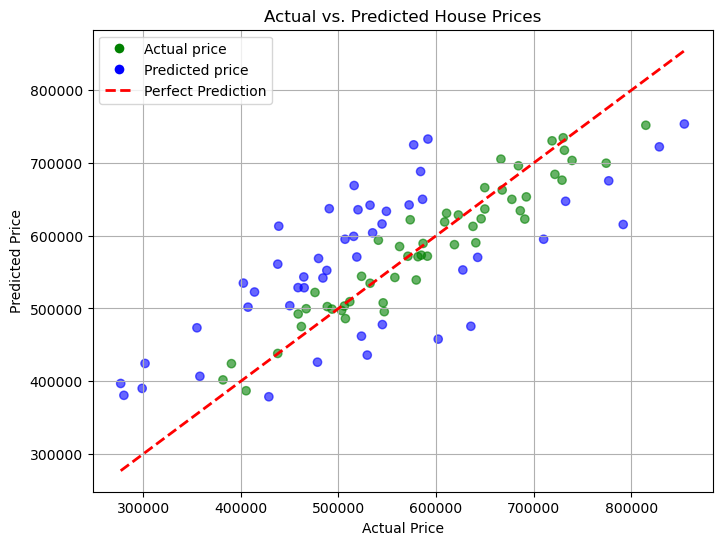

In [10]:
# Visualise the Predicted vs Actual Prices
# Create a scatter plot comparing the actual prices and predicted prices for the test set.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

# Define what counts as "accurate" - e.g. within 10% of actual price
threshold = 0.10
errors = np.abs(y_pred_multi - y_test_multi) / y_test_multi
colors = np.where(errors <= threshold, 'green', 'blue')

plt.figure(figsize=(8, 6))

plt.scatter(y_test_multi, y_pred_multi, c=colors, alpha=0.6)

# Add a diagonal line to show where the "Perfect Prediction" would be
# plot a line from the minimum price to the maximum price
plt.plot([y_test_multi.min(), y_test_multi.max()],
[y_test_multi.min(), y_test_multi.max()],
color='red',
lw=2,
linestyle='--')

legend_elements = [
Line2D([0], [0], marker='o', color='w', label='Actual price',
markerfacecolor='green', markersize=8),
Line2D([0], [0], marker='o', color='w', label='Predicted price',
markerfacecolor='blue', markersize=8),
Line2D([0], [0], color='red', lw=2, linestyle='--', label='Perfect Prediction')]

plt.legend(handles=legend_elements, loc='upper left')

plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

**Evaluate the RMSE (Root Mean Squared Error)**

In [11]:
# Evaluate the model using RMSE score 
rmse_multi = np.sqrt(mean_squared_error(y_test_multi, y_pred_multi))

print(f"Multiple Linear Regression RMSE: {rmse_multi:,.2f}")

Multiple Linear Regression RMSE: 75,017.18


In [12]:
print(df_house_price.columns.tolist())

['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Garage_Size', 'Location_Score', 'Distance_to_Center', 'Price']


**Interpret the results of the RMSE score**

 The RMSE score of 75K indicates an reasonable level of accuracy in this context, although it's not ideal if you were wanting an accurate house price prediction it's in the ball park but 75K is a noticeable difference in price.

**Insights from the visualisation**

In this scatterplot you can notice that the blue dots, which represent the predicted house prices of MLR model, are further away than the green dots (actual house price data). They are in the neighbourhood but not a close match. 
We can also notice that the actual prices are clustered close to the 'perfect prediction' (red dotted line) and that the predicted prices also generally follow that trend, albeit further away though.

## Compare with Random Forest Regressor

Now we will train a Random Forest Model
Train a Random Forest Regressor model and evaluate its performance.

Visualise Actual vs Predicted Prices for Random Forest
Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

Then Make the Model Comparison
Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?

In [13]:
# Task 4.1 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define features and target
X = df_house_price.drop('Price', axis=1)
y = df_house_price['Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model_rf = RandomForestRegressor(n_estimators=200, random_state=42)
model_rf.fit(X_train, y_train)

# Predict
y_pred_rf = model_rf.predict(X_test)

# Evaluate
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))


print(f"Random Forest RMSE: {rmse_rf:,.2f}")

🏃 View run cyan_bread_5rvq4t12 at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/d4f68d1f-12d1-42dc-a69c-db38ea54c7e5/#/experiments/f4cad2ce-359f-4bcd-9927-f1c8d21ffabf/runs/93fead07-e665-414b-9730-5223ae95b098
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/d4f68d1f-12d1-42dc-a69c-db38ea54c7e5/#/experiments/f4cad2ce-359f-4bcd-9927-f1c8d21ffabf


Random Forest RMSE: 72,013.13


**Evaluate Random Forest Regressor**

Random Forest performed better than MLR as the RMSE is marginally lower at 72K, than 75K for MLR.

     Actual Price  Predicted Price (Random Forest)
361   591058.7089                    500627.243247
73    667693.0003                    654256.956307
374   532377.5802                    561434.354749
155   478489.2990                    484593.849958
104   730197.4806                    757536.282477


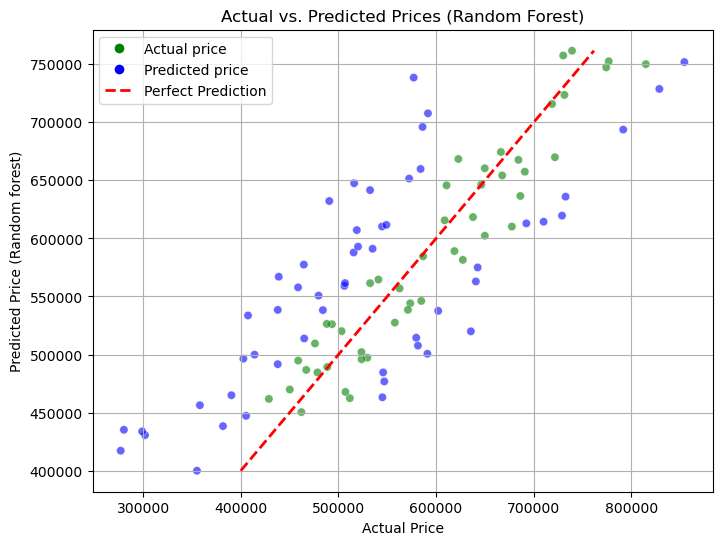

In [16]:
#task 4.2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from matplotlib.lines import Line2D

results_df_rf = pd.DataFrame({'Actual Price':y_test,'Predicted Price (Random Forest)':y_pred_rf})

print(results_df_rf.head(5))

# Define what counts as "accurate" -within 10% of actual price
threshold = 0.10
errors = np.abs(y_pred_rf - y_test) / y_test
colors = np.where(errors <= threshold, 'green', 'blue')

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf, c=colors , alpha=0.6)

# Add a digaonal line to show the "Perfect Prediction" would be
# Plot a line from the minimum to maximum price
plt.plot([y_pred_rf.min(), y_pred_rf.max()], 
[y_pred_rf.min(), y_pred_rf.max()], 
color='red', lw=2, linestyle='--')

# Lable the dots, green dot= actual price, blue dot= predicted price, use red dash line for 'Perfect Prediction'
legend_elements = [
Line2D([0], [0], marker='o', color='w', label='Actual price',
markerfacecolor='green', markersize=8),
Line2D([0], [0], marker='o', color='w', label='Predicted price',
markerfacecolor='blue', markersize=8),
Line2D([0], [0], color='red', lw=2, linestyle='--', label='Perfect Prediction')]

# Label the Legend
plt.legend(handles=legend_elements, loc='upper left')

plt.title('Actual vs. Predicted Prices (Random Forest)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price (Random forest)')
plt.grid(True)
plt.show()


In [15]:
#task 4.3
Comparison = pd.DataFrame({
    'Model': ['rmse_multi', 'rmse_rf'],
    'RMSE':[rmse_multi, rmse_rf]
})
print(Comparison)

        Model          RMSE
0  rmse_multi  75017.179302
1     rmse_rf  72013.130321


**Compare MLR and Random Forest Regressor**

Random Forest has performed somewhat better than MLR as the RMSE is lower at 72K, than 75K for MLR. But the difference is not significant.

## Conclusion and Insights

**Insights and Recommendation**

**Insights**

From performing two different model tests, we have found that Random Forest performs with a higher accuracy than MLR. The difference is about $3,004 (72,013 vs 75,017), Random Forest is performing slightly better, roughly a 4% improvement in prediction error. However given the results are in ~70,000 range we suspect that the data provided could be fabricated leading usually high results. 

Random forest is a better predictive modeling tool for this dataset as the relationship of house sales is non-linear (in that there are many variables that can drive a house sale up or down such as area or proximity to desired shops or amenities for instance not just number of rooms or square meters). Additionally Random Forrest also performs generally with less sensitivity to outliers than linear models, which is better for this dataset. 

**Recommendations**

MLR could possibly be improved with more independent variables in the train set, but this on its own may be minimal. 

House prices are dependent on a multitude of features therefore in order to increase accuracy for house price predictions. We recommend that dataset could be improved by including features such as year built, lot size (not just sqm2), condition, etc to gain greater accuracy for house price prediction. 

In addition to this, both MLR and Random Forest could be improved by increasing the amount of data used from 500 rows, to 1500 or 2000 rows may increase the predictions' accuracy. Usually this is tested in increments and by comparing results for each increment. 

Finally, if these improvements were made and the results were not vastly improved, we recommend using a boosting model that is best suited to this type of data such as; sklearn Gradient Boosting, XGBoost, LightGBM and CatBoost ^-^. These are considered superior for structured, tabular data and can capture complex patterns like those in house sales.
